In [3]:
# yfinance lets us download REAL live stock data from Yahoo Finance
# This is a real industry tool used by financial analysts
!pip install yfinance pandas numpy matplotlib seaborn

In [4]:
# ================================================
# PROJECT : Stock Market EDA & Analysis
# TOOLS   : Python, yfinance, Pandas, Seaborn
# STOCKS  : AAPL, MSFT, GOOGL, AMZN, NFLX
# GOAL    : Analyze 2 years of stock performance
#           and identify best performing stock
# ================================================

# --- Import all libraries ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# --- Chart settings ---
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
# --- Define our 5 stocks and time period ---
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NFLX"]

# Download 2 years of daily stock data
raw_data = yf.download(tickers, period="2y", auto_adjust=True)

print("✅ Data downloaded successfully!")
print("Shape:", raw_data.shape)
print("\nDate range:", raw_data.index[0].date(), "to", raw_data.index[-1].date())
print("\nColumns available:", raw_data.columns.get_level_values(0).unique().tolist())

[*********************100%***********************]  5 of 5 completed

✅ Data downloaded successfully!
Shape: (501, 25)

Date range: 2024-04-23 to 2026-04-22

Columns available: ['Close', 'High', 'Low', 'Open', 'Volume']


In [6]:
# ================================================
# PHASE 2: DATA CLEANING & EXPLORATION
# ================================================

# --- Extract only the 'Close' price for all 5 stocks ---
# Close price = the final price of the stock at end of each trading day
# This is the standard price used for all stock analysis

df = raw_data["Close"].copy()
df.index = pd.to_datetime(df.index)

print("✅ Close prices extracted!")
print("\nShape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

✅ Close prices extracted!

Shape: (501, 5)

First 5 rows:
Ticker            AAPL        AMZN       GOOGL        MSFT       NFLX
Date                                                                 
2024-04-23  165.394760  179.539993  156.962677  401.408936  57.775002
2024-04-24  167.495636  176.589996  157.825562  402.876373  55.512001
2024-04-25  168.357803  173.669998  154.721222  393.007843  56.480000
2024-04-26  167.773102  179.619995  170.540482  400.177795  56.123001
2024-04-29  171.935242  180.960007  164.788025  396.169342  55.949001


In [7]:
# --- Check for missing values ---
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
print(df.describe().round(2))

=== MISSING VALUES ===
Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
NFLX     0
dtype: int64

=== BASIC STATISTICS ===
Ticker    AAPL    AMZN   GOOGL    MSFT    NFLX
count   501.00  501.00  501.00  501.00  501.00
mean    231.23  209.19  212.48  440.09   93.42
std      26.42   21.36   60.20   45.13   20.79
min     165.39  161.02  144.20  351.87   55.06
25%     211.84  188.76  166.53  406.98   74.93
50%     228.60  210.64  182.77  426.35   93.38
75%     253.88  227.03  252.96  479.74  112.01
max     285.92  255.36  343.45  539.83  133.91


In [8]:
# --- Calculate important metrics for each stock ---

# 1. Total Return % — how much did the stock grow in 2 years?
total_return = ((df.iloc[-1] - df.iloc[0]) / df.iloc[0] * 100).round(2)

# 2. Current Price — latest closing price
current_price = df.iloc[-1].round(2)

# 3. Average Daily Volume is in raw_data — let's get avg price instead
avg_price = df.mean().round(2)

# 4. Volatility — standard deviation of daily returns (higher = more risky)
daily_returns = df.pct_change().dropna()
volatility = (daily_returns.std() * 100).round(2)

# --- Build a summary table ---
summary = pd.DataFrame({
    "Current Price ($)": current_price,
    "Avg Price 2Y ($)" : avg_price,
    "Total Return (%)": total_return,
    "Volatility (%)": volatility
})

print("=== STOCK PERFORMANCE SUMMARY ===")
print(summary.to_string())

=== STOCK PERFORMANCE SUMMARY ===
        Current Price ($)  Avg Price 2Y ($)  Total Return (%)  Volatility (%)
Ticker                                                                       
AAPL               273.17            231.23             65.16            1.79
AMZN               255.36            209.19             42.23            2.04
GOOGL              339.32            212.48            116.18            1.91
MSFT               432.92            440.09              7.85            1.55
NFLX                93.24             93.42             61.38            2.08


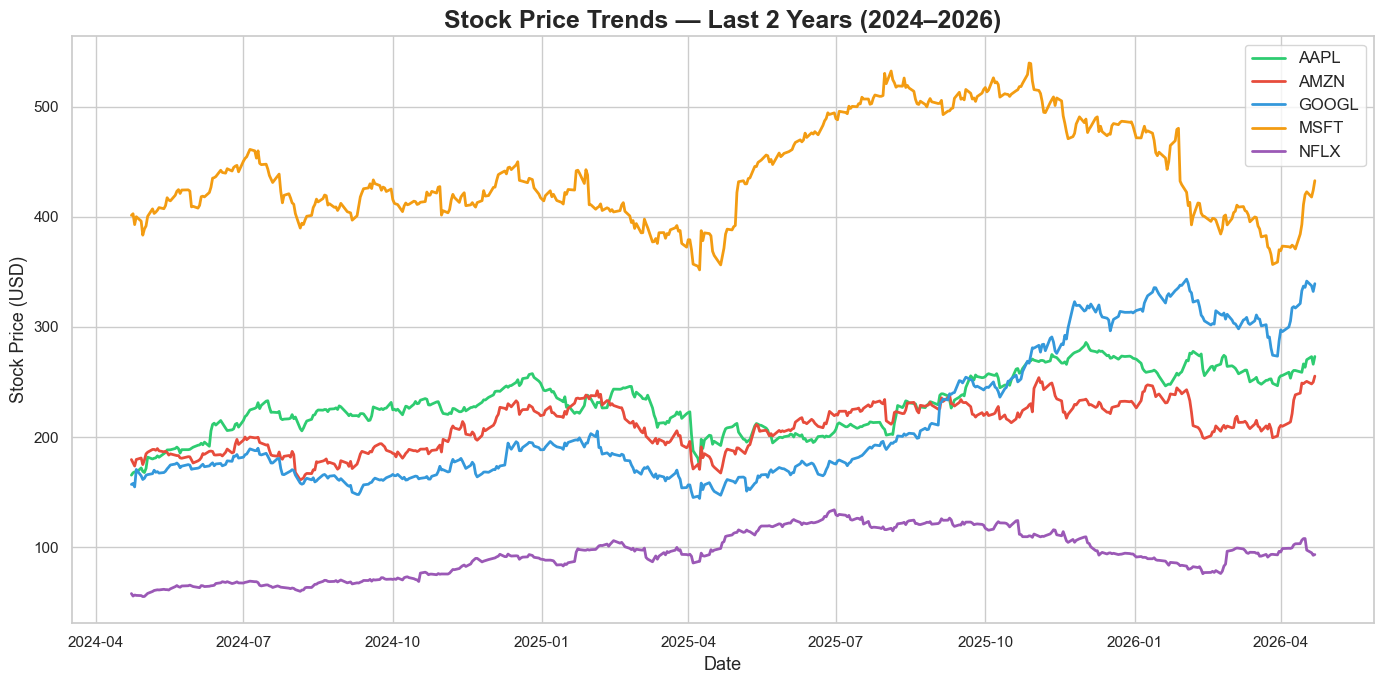

Chart 1 saved!


In [9]:
# ================================================
# PHASE 3: EDA + VISUALIZATIONS
# ================================================

# --- Chart 1: Price trends for all 5 stocks ---
colors = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12", "#9b59b6"]

plt.figure(figsize=(14, 7))
for i, ticker in enumerate(df.columns):
    plt.plot(df.index, df[ticker], label=ticker, color=colors[i], linewidth=2)

plt.title("Stock Price Trends — Last 2 Years (2024–2026)",
          fontsize=18, fontweight="bold")
plt.xlabel("Date", fontsize=13)
plt.ylabel("Stock Price (USD)", fontsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("chart1_price_trends.png", dpi=150)
plt.show()
print("Chart 1 saved!")

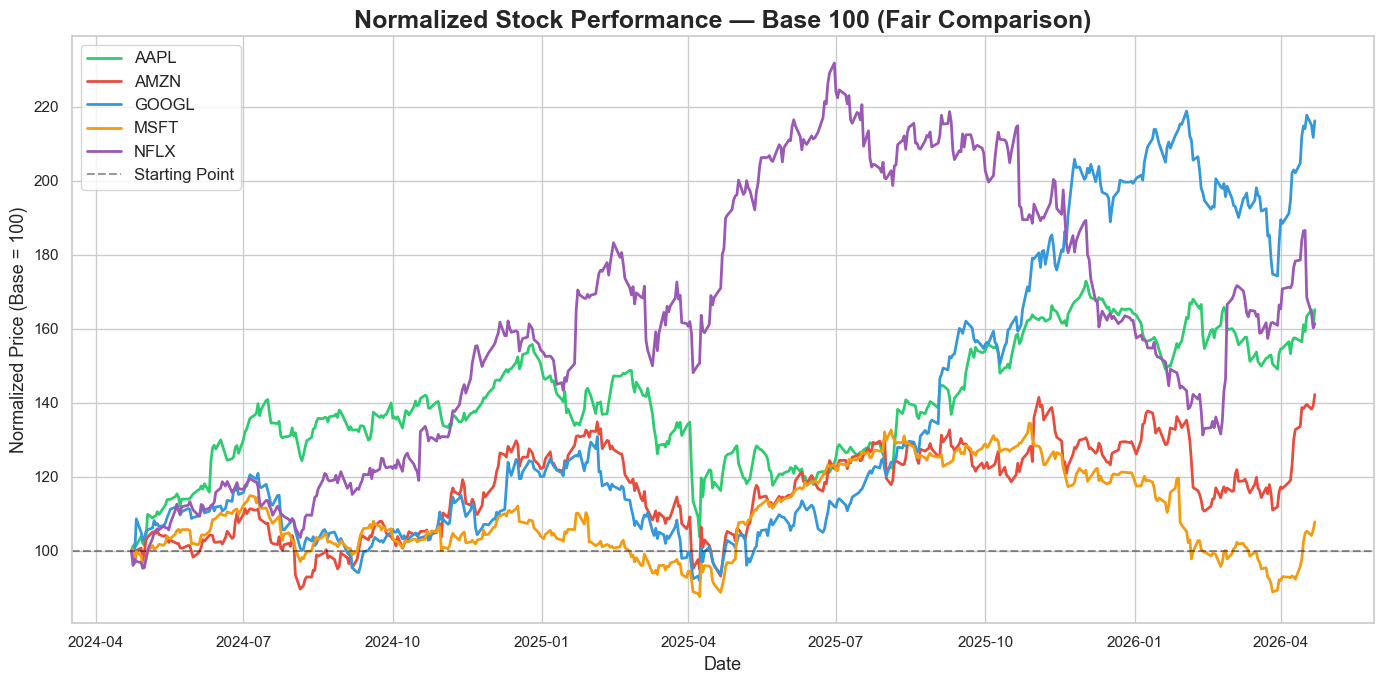

Chart 2 saved!


In [10]:
# --- Chart 2: Normalized price — starts everyone at 100 ---
# This is the CORRECT way to compare stocks with different prices
# e.g. MSFT at $400 vs NFLX at $57 — raw price comparison is unfair

normalized = (df / df.iloc[0]) * 100

plt.figure(figsize=(14, 7))
for i, ticker in enumerate(normalized.columns):
    plt.plot(normalized.index, normalized[ticker],
             label=ticker, color=colors[i], linewidth=2)

plt.axhline(y=100, color="black", linestyle="--", alpha=0.4, label="Starting Point")
plt.title("Normalized Stock Performance — Base 100 (Fair Comparison)",
          fontsize=18, fontweight="bold")
plt.xlabel("Date", fontsize=13)
plt.ylabel("Normalized Price (Base = 100)", fontsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("chart2_normalized.png", dpi=150)
plt.show()
print("Chart 2 saved!")

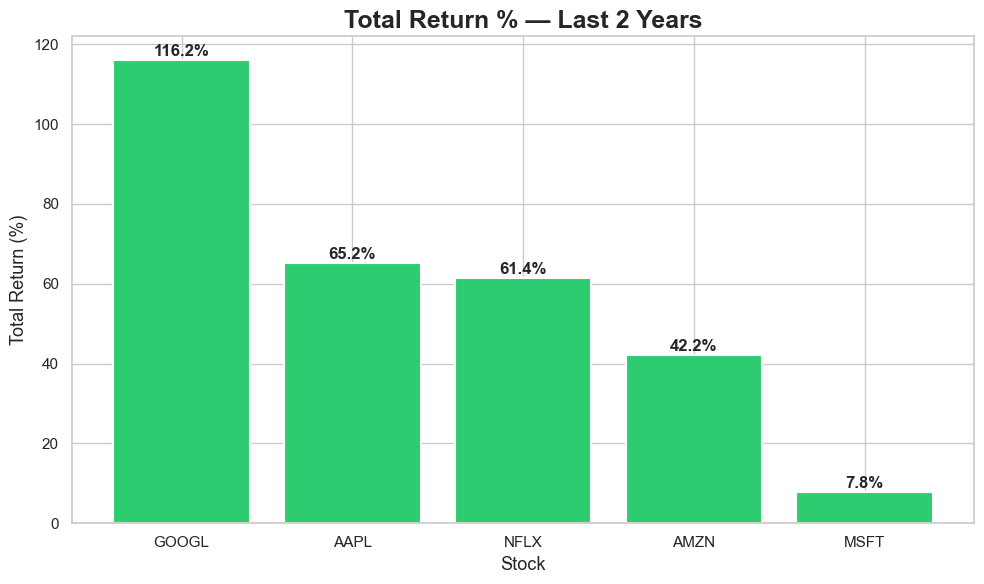

Chart 3 saved!


In [11]:
# --- Chart 3: Total return % bar chart ---
total_return_sorted = total_return.sort_values(ascending=False)
bar_colors = ["#2ecc71" if x > 0 else "#e74c3c" for x in total_return_sorted]

plt.figure(figsize=(10, 6))
bars = plt.bar(total_return_sorted.index, total_return_sorted.values,
               color=bar_colors, edgecolor="white", linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, total_return_sorted.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")

plt.title("Total Return % — Last 2 Years", fontsize=18, fontweight="bold")
plt.xlabel("Stock", fontsize=13)
plt.ylabel("Total Return (%)", fontsize=13)
plt.axhline(y=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("chart3_total_return.png", dpi=150)
plt.show()
print("Chart 3 saved!")

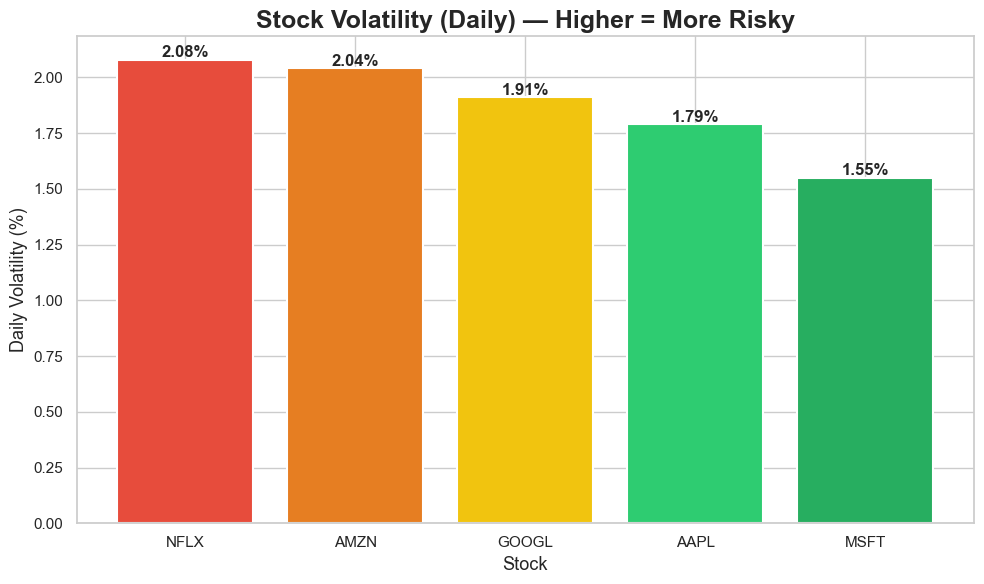

Chart 4 saved!


In [12]:
# --- Chart 4: Volatility = Risk ---
# Higher volatility = more unpredictable = more risky

volatility_sorted = volatility.sort_values(ascending=False)
vol_colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]

plt.figure(figsize=(10, 6))
bars2 = plt.bar(volatility_sorted.index, volatility_sorted.values,
                color=vol_colors, edgecolor="white", linewidth=1.5)

for bar, val in zip(bars2, volatility_sorted.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{val}%", ha="center", fontsize=12, fontweight="bold")

plt.title("Stock Volatility (Daily) — Higher = More Risky",
          fontsize=18, fontweight="bold")
plt.xlabel("Stock", fontsize=13)
plt.ylabel("Daily Volatility (%)", fontsize=13)
plt.tight_layout()
plt.savefig("chart4_volatility.png", dpi=150)
plt.show()
print("Chart 4 saved!")

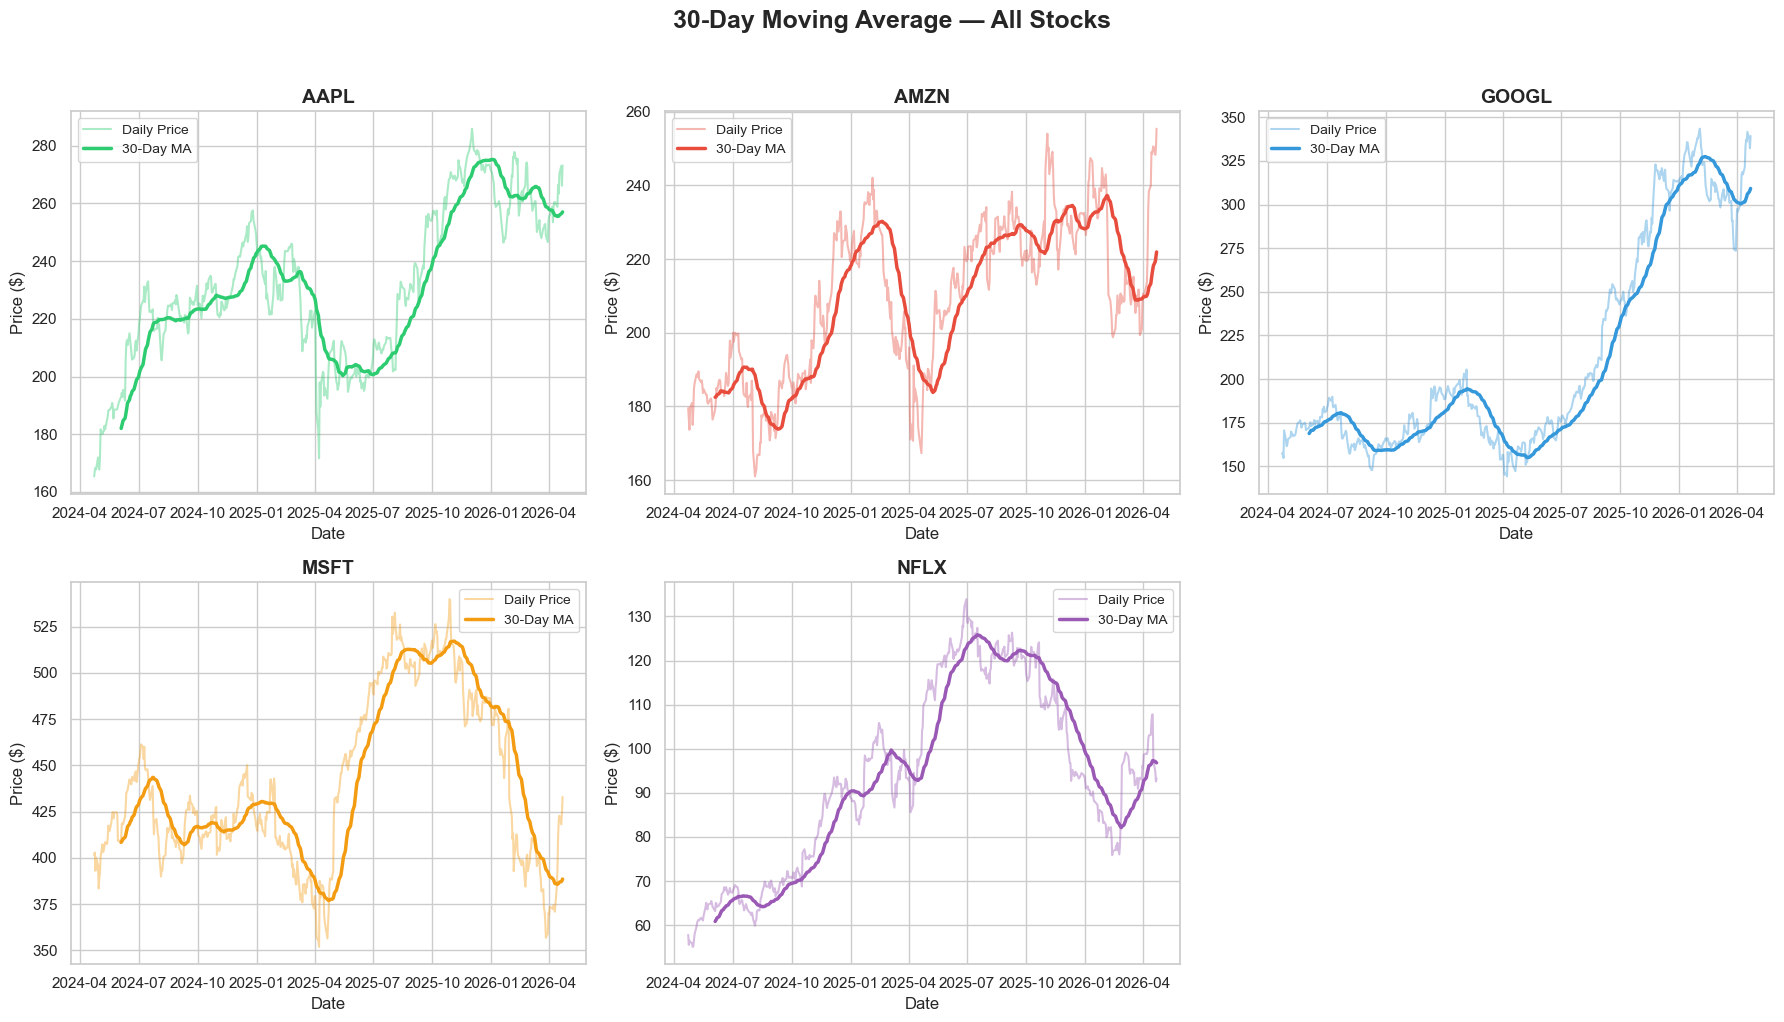

Chart 5 saved!


In [13]:
# --- Chart 5: 30-day moving average ---
# Moving average smooths out daily noise and shows the real trend
# This is used by every financial analyst in the world

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ticker in enumerate(df.columns):
    ma30 = df[ticker].rolling(window=30).mean()
    axes[i].plot(df.index, df[ticker], alpha=0.4,
                 color=colors[i], label="Daily Price")
    axes[i].plot(df.index, ma30, color=colors[i],
                 linewidth=2.5, label="30-Day MA")
    axes[i].set_title(ticker, fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Price ($)")
    axes[i].legend(fontsize=10)

# Hide the 6th empty subplot
axes[5].set_visible(False)

plt.suptitle("30-Day Moving Average — All Stocks",
             fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("chart5_moving_average.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved!")

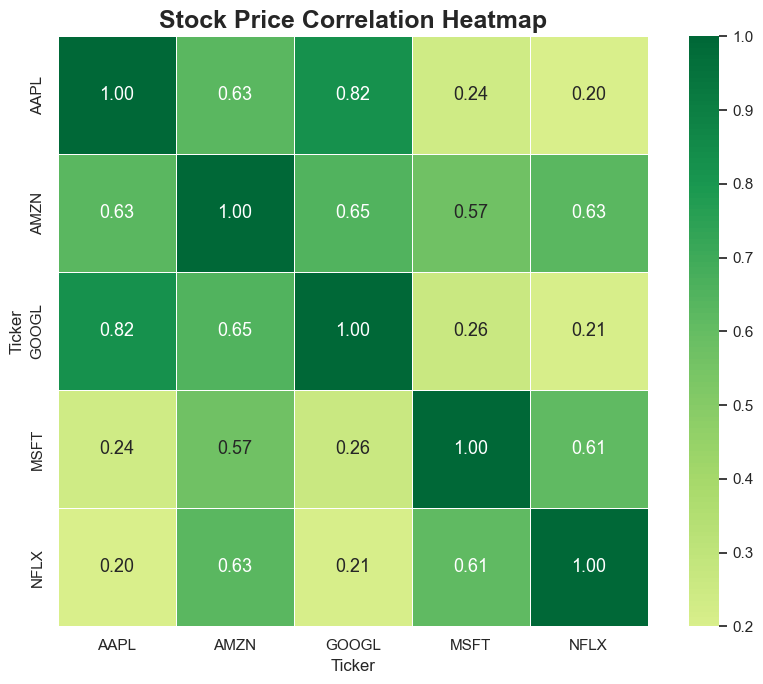

Chart 6 saved!


In [14]:
# --- Chart 6: Correlation between stocks ---
# Do stocks move together or independently?

plt.figure(figsize=(9, 7))
corr_matrix = df.corr().round(2)

sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0,
            linewidths=0.5, annot_kws={"size": 13},
            square=True)

plt.title("Stock Price Correlation Heatmap",
          fontsize=18, fontweight="bold")
plt.tight_layout()
plt.savefig("chart6_correlation.png", dpi=150)
plt.show()
print("Chart 6 saved!")

In [15]:
# ================================================
# PHASE 5: KEY BUSINESS INSIGHTS & RECOMMENDATIONS
# ================================================

summary = """
╔══════════════════════════════════════════════════════════════════╗
║           STOCK MARKET EDA — KEY FINDINGS                        ║
║           5 Tech Stocks | Apr 2024 – Apr 2026                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET : 501 trading days | 5 stocks | Live via yfinance      ║
║  TOOLS   : Python, Pandas, yfinance, Seaborn, Matplotlib        ║
║  AUTHOR  : Devendra                                              ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  INSIGHT 1 — Best Performing Stock                               ║
║  GOOGL delivered 116.2% return over 2 years                     ║
║  → $1,00,000 invested in GOOGL = $2,16,200 today               ║
║                                                                  ║
║  INSIGHT 2 — Worst Performing Stock                              ║
║  MSFT delivered only 7.8% return despite highest price ($432)   ║
║  → High price does NOT mean high returns                        ║
║                                                                  ║
║  INSIGHT 3 — Risk vs Return                                      ║
║  NFLX  : Highest risk (2.08%) + 61.4% return                   ║
║  MSFT  : Lowest risk (1.55%) + only 7.8% return                ║
║  GOOGL : Medium risk (1.91%) + BEST return (116.2%)             ║
║  → GOOGL offered the best risk-adjusted performance             ║
║                                                                  ║
║  INSIGHT 4 — Market Correlation                                  ║
║  AAPL & GOOGL move together (0.82 correlation)                  ║
║  MSFT moves more independently from AAPL (0.24)                 ║
║  → Diversifying between MSFT and AAPL reduces portfolio risk   ║
║                                                                  ║
║  INSIGHT 5 — Trend Observation                                   ║
║  GOOGL was flat for 12 months then surged 100%+ from mid-2025  ║
║  MSFT peaked at $539 in late 2025 then declined sharply        ║
║  → Timing and trend analysis matters as much as stock picking  ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  RECOMMENDATIONS FOR AN INVESTOR                                 ║
║                                                                  ║
║  REC 1: GOOGL is the strongest pick for growth investors        ║
║  REC 2: MSFT suits conservative investors — low risk            ║
║  REC 3: Combine AAPL + MSFT for diversification (low 0.24 corr)║
║  REC 4: Avoid NFLX for low-risk portfolios — highest volatility ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(summary)

# --- Save final clean data for Power BI ---
df_powerbi = df.copy()
df_powerbi.index.name = "Date"
df_powerbi = df_powerbi.reset_index()
df_powerbi["Date"] = df_powerbi["Date"].dt.strftime("%Y-%m-%d")

# Also add daily returns
for ticker in ["AAPL", "AMZN", "GOOGL", "MSFT", "NFLX"]:
    df_powerbi[f"{ticker}_Return%"] = (
        df[ticker].pct_change() * 100
    ).round(4).values

df_powerbi.to_csv("stock_data_for_powerbi.csv", index=False)
print("\n✅ Data saved for Power BI → stock_data_for_powerbi.csv")


╔══════════════════════════════════════════════════════════════════╗
║           STOCK MARKET EDA — KEY FINDINGS                        ║
║           5 Tech Stocks | Apr 2024 – Apr 2026                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET : 501 trading days | 5 stocks | Live via yfinance      ║
║  TOOLS   : Python, Pandas, yfinance, Seaborn, Matplotlib        ║
║  AUTHOR  : Devendra                                              ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  INSIGHT 1 — Best Performing Stock                               ║
║  GOOGL delivered 116.2% return over 2 years                     ║
║  → $1,00,000 invested in GOOGL = $2,16,200 today               ║
║                                                                  ║
║  INSIGHT 2 — Worst Performing Stock  